Confusion matrix:
 [[58  2]
 [ 3 57]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        60
           1       0.97      0.95      0.96        60

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



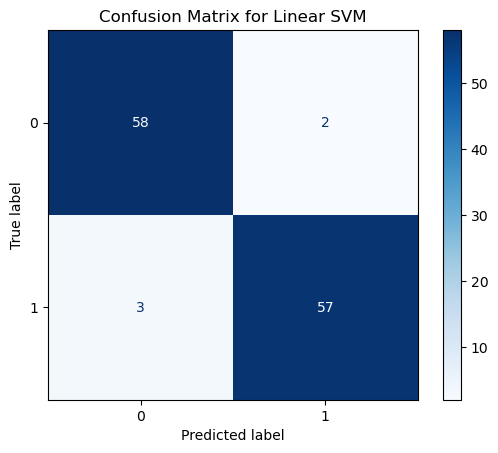

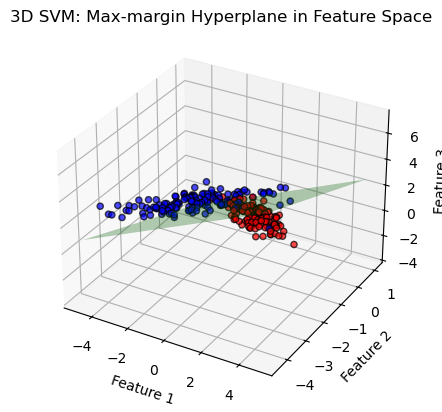

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Generate a 3D synthetic dataset for binary classification
X, y = make_classification(
    n_samples=400,
    n_features=3,       # three numerical attributes
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Train a linear SVM (max-margin hyperplane in R^3)
svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train, y_train)

# 4. Predictions and evaluation on the test set
y_pred = svm_clf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred))
# 5. Visualise confusion matrix with colours
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_clf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Linear SVM')
plt.show()

# 6. Extract the geometric hyperplane parameters
w = svm_clf.coef_[0]   # normal vector to the plane in R^3
b = svm_clf.intercept_[0]

# 7. 3D scatter plot plus decision plane
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot training points
ax.scatter(
    X_train[:, 0], X_train[:, 1], X_train[:, 2],
    c=y_train, cmap='bwr', edgecolor='k', alpha=0.7
)

# Create a grid for the decision plane
x_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 10)
y_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 10)
xx, yy = np.meshgrid(x_range, y_range)

# Solve for z on the plane w1*x + w2*y + w3*z + b = 0
if abs(w[2]) > 1e-6:
    zz = -(w[0] * xx + w[1] * yy + b) / w[2]
    ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('3D SVM: Max-margin Hyperplane in Feature Space')
plt.show()